In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re


# **Data Overview**

In [2]:
df = pd.read_parquet(
    "https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet",
    engine="pyarrow"
)

df.shape
df.head(10)

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -..."
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...
5,https://citylife.capetown/lb/uncategorized/how...,2023-12-12,en,Google Releases New Chatbot Bard as a Strong C...,Google Releases New Chatbot Bard as a Strong ...
6,https://citylife.capetown/technology/zoom-laun...,2023-09-07,en,Zoom Expands AI Offering with AI Companion and...,Zoom Expands AI Offering with AI Companion an...
7,https://citylife.capetown/uncategorized/pro-ai...,2023-08-04,en,Pro-AI Thinking: Enhancing Industrial Environm...,\n\nPro-AI Thinking: Enhancing Industrial Envi...
8,https://clickup.com/ai/prompts/business-risk-m...,2024-03-13,en,Best AI Prompts for Business Risk Management,Best AI Prompts for Business Risk ManagementPr...
9,https://crooksandliars.com/2025/12/state-ags-w...,2025-12-15,en,State AGs Warn AI Companies: Clean Up Your Chi...,\nState AGs Warn AI Companies: Clean Up Your C...


In [3]:
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()


Columns: ['url', 'date', 'language', 'title', 'text']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       199989 non-null  object
 1   date      199989 non-null  object
 2   language  199989 non-null  object
 3   title     199989 non-null  object
 4   text      199989 non-null  object
dtypes: object(5)
memory usage: 7.6+ MB


In [4]:
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(3)

missing_summary = (
    pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
      .sort_values("missing_count", ascending=False)
)

print("\nMissingness summary:")
display(missing_summary)


Missingness summary:


,missing_count,missing_pct
url,0,0.0
date,0,0.0
language,0,0.0
title,0,0.0
text,0,0.0


In [5]:
miss_nonzero = missing_summary[missing_summary["missing_count"] > 0]
if len(miss_nonzero) > 0:
    plt.figure()
    plt.bar(miss_nonzero.index, miss_nonzero["missing_count"])
    plt.title("Missing Values by Column")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count missing")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values detected in any column.")



No missing values detected in any column.



Blank/empty strings (not NA):


,blank_count,blank_pct
title,0,0.0
text,0,0.0



Title length summary:


,title_len
count,199989.000000
mean,86.643300
std,37.644607
min,6.000000
1%,35.000000
5%,49.000000
25%,66.000000
50%,82.000000
75%,102.000000
95%,140.000000



Text length summary:


,text_len
count,199989.000000
mean,9098.766462
std,7264.733714
min,21.000000
1%,867.000000
5%,1466.400000
25%,5245.000000
50%,7622.000000
75%,11390.000000
95%,19415.600000


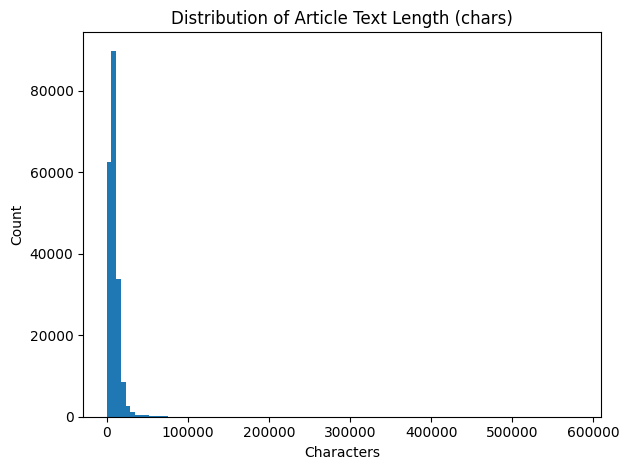

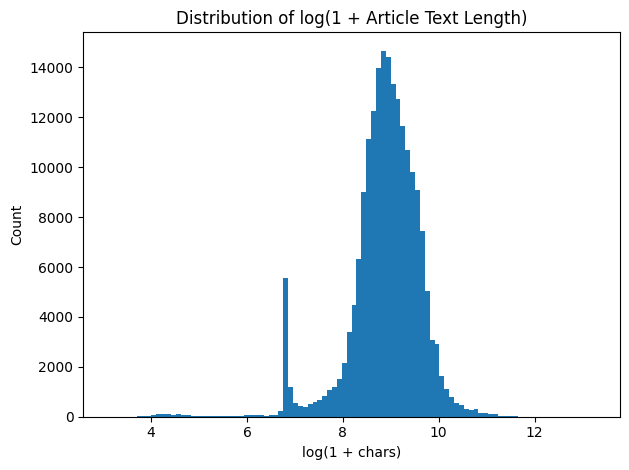


Date parsing:
Unparseable dates: 0
Min date: 2022-01-01 00:00:00
Max date: 2026-02-10 00:00:00


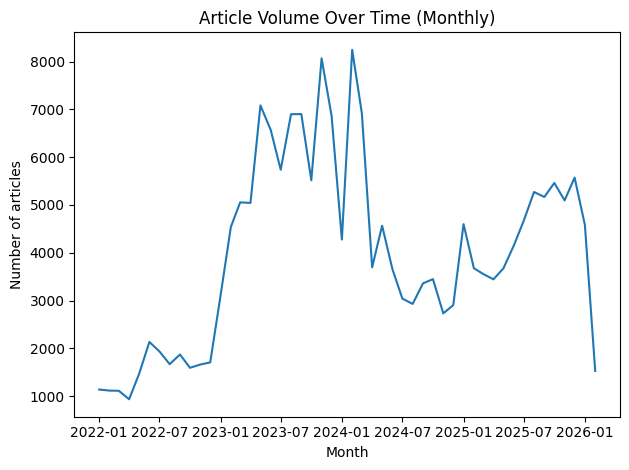


Top languages:


,count
language,
en,199989



Top domains:


,count
domain,
www.rawpixel.com,7315
menafn.com,4093
www.einpresswire.com,3829
citylife.capetown,3265
www.prnewswire.com,2857
www.nasdaq.com,2548
www.mexc.co,2317
www.livemint.com,1865
economictimes.indiatimes.com,1701


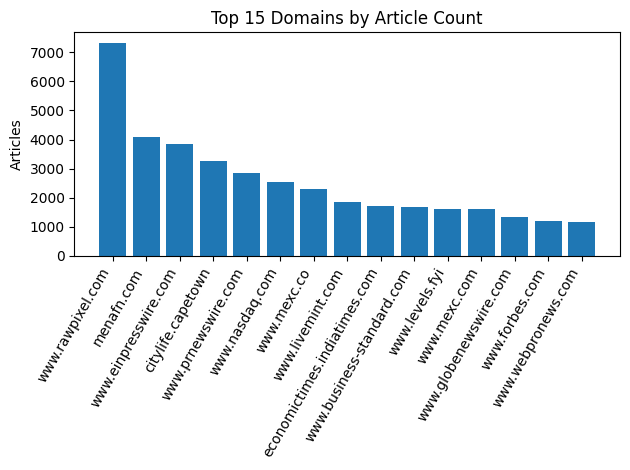


Duplicate counts:
Duplicate URL: 0
Duplicate Title: 35684
Duplicate Text: 494


In [6]:
# Create lightweight length features (NOT preprocessing text content itself)
df["title_len"] = df["title"].astype(str).str.len()
df["text_len"] = df["text"].astype(str).str.len()

# % empty/whitespace-only (different from NA)
df["title_blank"] = df["title"].astype(str).str.strip().eq("")
df["text_blank"] = df["text"].astype(str).str.strip().eq("")

blank_summary = pd.DataFrame({
    "blank_count": [df["title_blank"].sum(), df["text_blank"].sum()],
    "blank_pct": [df["title_blank"].mean()*100, df["text_blank"].mean()*100]
}, index=["title", "text"]).round(3)

print("\nBlank/empty strings (not NA):")
display(blank_summary)

print("\nTitle length summary:")
display(df["title_len"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

print("\nText length summary:")
display(df["text_len"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

# Visual: distributions (use log scale view too because there may be huge outliers)
plt.figure()
plt.hist(df["text_len"], bins=100)
plt.title("Distribution of Article Text Length (chars)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(np.log1p(df["text_len"]), bins=100)
plt.title("Distribution of log(1 + Article Text Length)")
plt.xlabel("log(1 + chars)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Date parsing + coverage over time
# Convert date safely
df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")

print("\nDate parsing:")
print("Unparseable dates:", df["date_parsed"].isna().sum())

if df["date_parsed"].notna().any():
    print("Min date:", df["date_parsed"].min())
    print("Max date:", df["date_parsed"].max())

    # Volume over time (monthly)
    monthly_counts = (
        df.dropna(subset=["date_parsed"])
          .set_index("date_parsed")
          .resample("MS")["url"]
          .count()
          .rename("article_count")
          .reset_index()
    )

    plt.figure()
    plt.plot(monthly_counts["date_parsed"], monthly_counts["article_count"])
    plt.title("Article Volume Over Time (Monthly)")
    plt.xlabel("Month")
    plt.ylabel("Number of articles")
    plt.tight_layout()
    plt.show()

#  Language + source domain quick checks
print("\nTop languages:")
display(df["language"].value_counts().head(10))

# Extract domain from url (helps spot syndication / noisy sources)
# (No external packages needed)
df["domain"] = (
    df["url"].astype(str)
      .str.replace(r"^https?://", "", regex=True)
      .str.split("/", n=1).str[0]
      .str.lower()
)

print("\nTop domains:")
display(df["domain"].value_counts().head(20))

top_domains = df["domain"].value_counts().head(15)
plt.figure()
plt.bar(top_domains.index, top_domains.values)
plt.title("Top 15 Domains by Article Count")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Articles")
plt.tight_layout()
plt.show()

# 6) Duplicate diagnostics (for understanding, not filtering yet)
dup_text = df.duplicated(subset=["text"]).sum()
dup_title = df.duplicated(subset=["title"]).sum()
dup_url = df.duplicated(subset=["url"]).sum()

print("\nDuplicate counts:")
print("Duplicate URL:", dup_url)
print("Duplicate Title:", dup_title)
print("Duplicate Text:", dup_text)


The dataset contains **199,989** English-language news articles related to artificial intelligence, machine learning, and data science. Each article includes five fields: url, date, language, title, and text. There are no missing values across any of these columns, and no blank or empty text entries were detected.

The articles span from **January 2022 through early 2026**, with article volume varying over time. Monthly publication counts show a sharp increase beginning in early 2023, peaking around late 2023 to early 2024 (approximately 7,000–8,000 articles per month), followed by a moderate decline and stabilization in 2025. The drop at the very end of the timeline likely reflects partial data collection for 2026 rather than a real decrease in coverage.

**Text Length Distribution**

Article lengths vary substantially:

- Mean text length: ~9,099 characters
- Median text length: ~7,622 characters
- 1st percentile: 867 characters
- 99th percentile: 33,832 characters
- Maximum length: 580,772 characters

The distribution is strongly right-skewed, with a small number of extremely long articles that are likely web-scraping artifacts (e.g., full HTML dumps or aggregated content). Most articles fall between roughly 1,500 and 20,000 characters, indicating substantial substantive content.

**Title lengths are much more stable:**

- Mean title length: ~87 characters
- Median title length: 82 characters
- Very few extreme outliers (max = 8,250 characters)

Duplicate Analysis

- Duplicate URLs: 0
- Duplicate titles: 35,684 (~18% of dataset)
- Duplicate full text entries: 494

The high number of duplicate titles suggests syndicated or similarly framed reporting across multiple outlets, but full article duplication is relatively rare (only ~0.25%), indicating strong content diversity overall.

# **Data Cleaning**

In [7]:
#Remove exact duplicate full-text articles
df = df.drop_duplicates(subset=["text"]).copy()

#Create text length feature
df["text_len"] = df["text"].astype(str).str.len()

#Remove very short articles (likely crawl noise)
df = df[df["text_len"] > 500]

# Remove extreme length outliers (top 1%)
upper_bound = df["text_len"].quantile(0.99)
df = df[df["text_len"] < upper_bound]

# Light structural cleaning
def basic_clean(text):
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"\n+", " ", text)      # collapse newlines
    text = re.sub(r"\s+", " ", text)      # normalize whitespace
    return text.strip()

df["clean_text"] = df["text"].apply(basic_clean)

print("Final shape:", df.shape)
print("Text length summary:")
print(df["text_len"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

Final shape: (196276, 12)
Text length summary:
count    196276.000000
mean       8722.713235
std        5120.519351
min         501.000000
1%          889.000000
5%         1789.750000
25%        5266.000000
50%        7601.000000
75%       11261.000000
95%       18387.000000
99%       25851.000000
max       33928.000000
Name: text_len, dtype: float64


Unparseable dates: 0
Date range: 2022-01-01 00:00:00 to 2026-02-10 00:00:00

Top 10 domains:
domain
www.rawpixel.com                7315
menafn.com                      4089
www.einpresswire.com            3821
citylife.capetown               3265
www.prnewswire.com              2838
www.nasdaq.com                  2533
www.mexc.co                     2283
www.livemint.com                1864
economictimes.indiatimes.com    1697
www.business-standard.com       1667
Name: count, dtype: int64

Final dataset shape: (196276, 12)

Remaining duplicate text count: 0


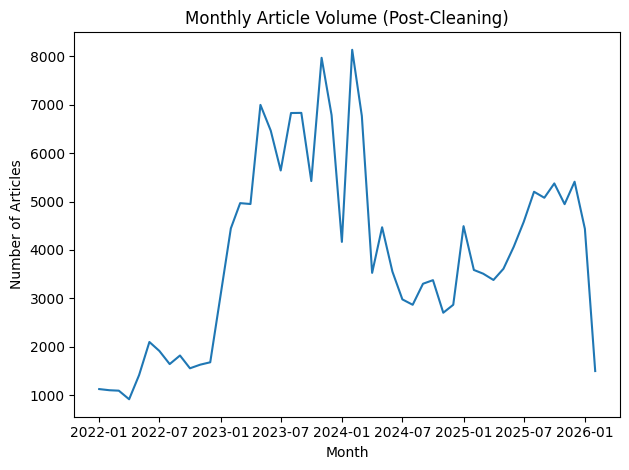

In [8]:
#  Standardize Date Column

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Unparseable dates:", df["date"].isna().sum())
print("Date range:", df["date"].min(), "to", df["date"].max())

# Extract Domain from URL (for source analysis)
df["domain"] = (
    df["url"]
    .str.replace(r"^https?://", "", regex=True)
    .str.split("/", n=1)
    .str[0]
    .str.lower()
)

print("\nTop 10 domains:")
print(df["domain"].value_counts().head(10))


# Final Sanity Checks
print("\nFinal dataset shape:", df.shape)

print("\nRemaining duplicate text count:",
      df.duplicated(subset=["text"]).sum())


# Monthly Article Volume (Post-Cleaning)
monthly_counts = (
    df.set_index("date")
      .resample("MS")["url"]
      .count()
      .rename("article_count")
      .reset_index()
)


plt.figure()
plt.plot(monthly_counts["date"], monthly_counts["article_count"])
plt.title("Monthly Article Volume (Post-Cleaning)")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

In [9]:
df = df.drop(columns=["date"])
df = df.rename(columns={"date_parsed": "date"})
df = df.drop(columns=["title_blank", "text_blank"])

In [10]:
# Check unique language values
print("Unique language values:")
print(df["language"].value_counts(dropna=False))

Unique language values:
language
en    196276
Name: count, dtype: int64


In [ ]:
df.head(5)

,url,language,title,text,title_len,text_len,date,domain,clean_text
0,https://blockworks.co/price/bad,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",77,3501,2025-06-23,blockworks.co,"Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,78,5585,2024-07-01,boingboing.net,This AI video of gymnastics might be the freak...
2,https://boingboing.net/2024/09/18/if-using-ai-...,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",54,5880,2024-09-22,boingboing.net,"If using AI feels like a chore, try this - Boi..."
3,https://citylife.capetown/gl/uncategorized/the...,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,102,4072,2023-11-10,citylife.capetown,The Road Ahead: How China's AI Foundation Mode...
4,https://citylife.capetown/kk/uncategorized/mic...,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,65,4347,2023-11-19,citylife.capetown,Microsoft and Nvidia to Empower Developers wit...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_path_csv = "/content/drive/MyDrive/nlp/final project/clean_base_dataset.csv"
df[["url","date","title","clean_text","text_len","domain"]].to_csv(save_path_csv, index=False)
print("Saved CSV:", save_path_csv)

Saved CSV: /content/drive/MyDrive/nlp/final project/clean_base_dataset.csv
